In [1]:
import numpy as np, pandas as pd

In [2]:
df = pd.read_csv("Iris.csv")

In [3]:
df

,sepal length,sepal width,petal length,petal width,iris
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [5]:
X = df.drop("iris", axis=1)
y = df["iris"]

In [6]:
X

,sepal length,sepal width,petal length,petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_transformed = scaler.fit_transform(X)

In [10]:
X_transformed

array([[0.22222222, 0.625     , 0.06779661, 0.04166667],
       [0.16666667, 0.41666667, 0.06779661, 0.04166667],
       [0.11111111, 0.5       , 0.05084746, 0.04166667],
       [0.08333333, 0.45833333, 0.08474576, 0.04166667],
       [0.19444444, 0.66666667, 0.06779661, 0.04166667],
       [0.30555556, 0.79166667, 0.11864407, 0.125     ],
       [0.08333333, 0.58333333, 0.06779661, 0.08333333],
       [0.19444444, 0.58333333, 0.08474576, 0.04166667],
       [0.02777778, 0.375     , 0.06779661, 0.04166667],
       [0.16666667, 0.45833333, 0.08474576, 0.        ],
       [0.30555556, 0.70833333, 0.08474576, 0.04166667],
       [0.13888889, 0.58333333, 0.10169492, 0.04166667],
       [0.13888889, 0.41666667, 0.06779661, 0.        ],
       [0.        , 0.41666667, 0.01694915, 0.        ],
       [0.41666667, 0.83333333, 0.03389831, 0.04166667],
       [0.38888889, 1.        , 0.08474576, 0.125     ],
       [0.30555556, 0.79166667, 0.05084746, 0.125     ],
       [0.22222222, 0.625     ,

In [4]:
from sklearn.decomposition import PCA

In [13]:
pca = PCA(random_state=42)

In [14]:
help(pca)

Help on PCA in module sklearn.decomposition._pca object:

class PCA(sklearn.decomposition._base._BasePCA)
 |  PCA(n_components=None, *, copy=True, whiten=False, svd_solver='auto', tol=0.0, iterated_power='auto', n_oversamples=10, power_iteration_normalizer='auto', random_state=None)
 |
 |  Principal component analysis (PCA).
 |
 |  Linear dimensionality reduction using Singular Value Decomposition of the
 |  data to project it to a lower dimensional space. The input data is centered
 |  but not scaled for each feature before applying the SVD.
 |
 |  It uses the LAPACK implementation of the full SVD or a randomized truncated
 |  SVD by the method of Halko et al. 2009, depending on the shape of the input
 |  data and the number of components to extract.
 |
 |  With sparse inputs, the ARPACK implementation of the truncated SVD can be
 |  used (i.e. through :func:`scipy.sparse.linalg.svds`). Alternatively, one
 |  may consider :class:`TruncatedSVD` where the data are not centered.
 |
 |  N

In [15]:
pca.fit(X_transformed)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,42


In [16]:
pca.components_

array([[ 0.4252893 , -0.14612219,  0.61610511,  0.64667752],
       [ 0.42100611,  0.90470509, -0.06432645, -0.01116485],
       [ 0.71434339, -0.33510219,  0.06825927, -0.61054133],
       [-0.36276216,  0.21877734,  0.78205964, -0.45708076]])

In [17]:
pca.explained_variance_ratio_

array([0.84141901, 0.11732474, 0.03490564, 0.00635061])

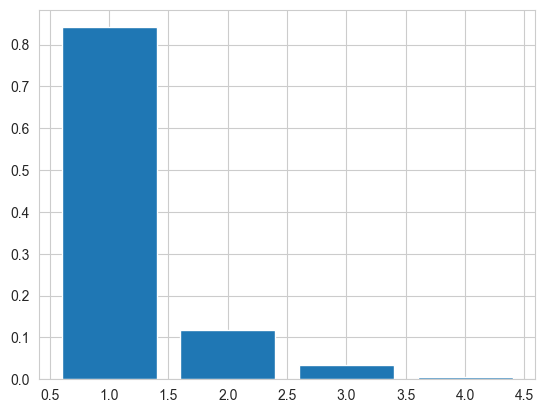

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.bar((range(1, 5)), pca.explained_variance_ratio_)
plt.show()

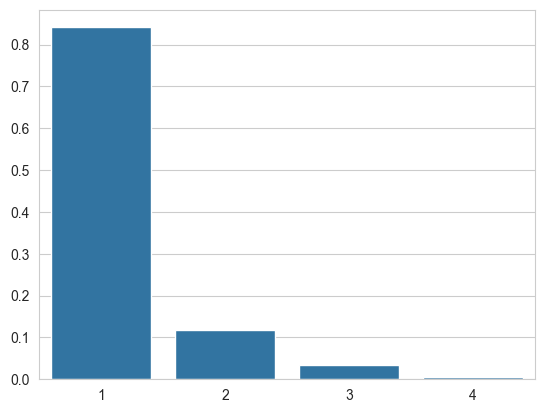

In [26]:
sns.barplot(x=range(1, 5), y=pca.explained_variance_ratio_)
plt.show()

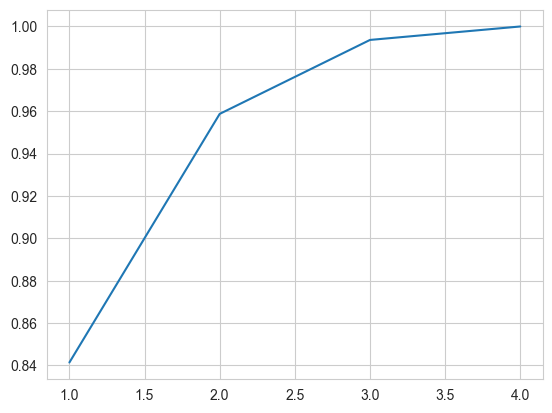

In [28]:
var_cum_sum = np.cumsum(pca.explained_variance_ratio_)
sns.lineplot(x=range(1, len(var_cum_sum) + 1), y=var_cum_sum)
plt.show()

In [29]:
var_cum_sum

array([0.84141901, 0.95874375, 0.99364939, 1.        ])

In [30]:
pc2 = PCA(n_components=2, random_state=42)
new_data = pc2.fit_transform(X_transformed)
new_data

array([[-6.30361249e-01,  1.11556258e-01],
       [-6.23546310e-01, -1.00313199e-01],
       [-6.69792802e-01, -4.72200571e-02],
       [-6.54633051e-01, -9.87912747e-02],
       [-6.48263265e-01,  1.37557689e-01],
       [-5.34057000e-01,  2.93223042e-01],
       [-6.56395887e-01,  1.49219390e-02],
       [-6.25643957e-01,  6.10753191e-02],
       [-6.76525845e-01, -1.96482315e-01],
       [-6.46137172e-01, -6.32422300e-02],
       [-5.96654863e-01,  2.20941913e-01],
       [-6.38828681e-01,  3.65958117e-02],
       [-6.62304799e-01, -1.11542611e-01],
       [-7.52700136e-01, -1.66744846e-01],
       [-5.98993148e-01,  3.84079343e-01],
       [-5.49943265e-01,  5.18967671e-01],
       [-5.75826838e-01,  2.97584158e-01],
       [-6.03416352e-01,  1.11091056e-01],
       [-5.19472697e-01,  2.91076041e-01],
       [-6.11239166e-01,  2.23088914e-01],
       [-5.57504671e-01,  1.05673218e-01],
       [-5.78205845e-01,  1.84927666e-01],
       [-7.37287470e-01,  9.51403474e-02],
       [-5.

In [32]:
df2 = pd.concat([pd.DataFrame(new_data, columns=["PC1", "PC2"]), y], axis=1)
df2

,PC1,PC2,iris
0,-0.630361,0.111556,Iris-setosa
1,-0.623546,-0.100313,Iris-setosa
2,-0.669793,-0.047220,Iris-setosa
3,-0.654633,-0.098791,Iris-setosa
4,-0.648263,0.137558,Iris-setosa
...,...,...,...
145,0.551755,0.058990,Iris-virginica
146,0.406278,-0.172227,Iris-virginica
147,0.447293,0.036996,Iris-virginica
148,0.489218,0.149121,Iris-virginica


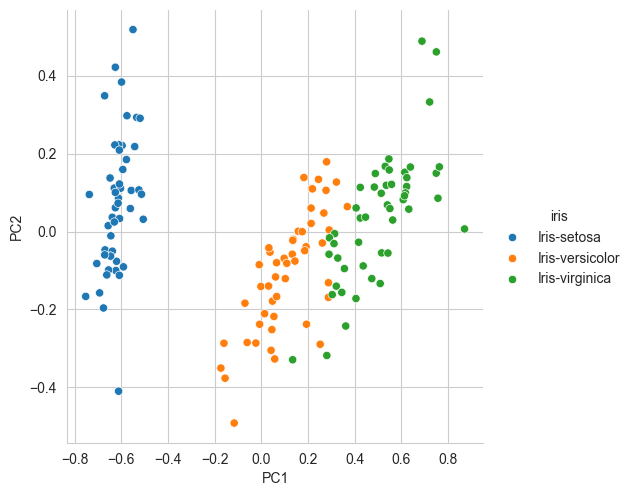

In [35]:
sns.pairplot(data=df2, x_vars=["PC1"], y_vars=["PC2"], hue="iris", height=5)
plt.show()

In [40]:
a = pca.fit()

In [41]:
a.components_

array([[ 0.36158968, -0.08226889,  0.85657211,  0.35884393],
       [ 0.65653988,  0.72971237, -0.1757674 , -0.07470647],
       [-0.58099728,  0.59641809,  0.07252408,  0.54906091],
       [ 0.31725455, -0.32409435, -0.47971899,  0.75112056]])

In [43]:
a.explained_variance_ratio_

array([0.92461621, 0.05301557, 0.01718514, 0.00518309])

In [39]:
help(pca.fit_transform)

Help on method fit_transform in module sklearn.decomposition._pca:

fit_transform(X, y=None) method of sklearn.decomposition._pca.PCA instance
    Fit the model with X and apply the dimensionality reduction on X.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training data, where `n_samples` is the number of samples
        and `n_features` is the number of features.

    y : Ignored
        Ignored.

    Returns
    -------
    X_new : ndarray of shape (n_samples, n_components)
        Transformed values.

    Notes
    -----
    This method returns a Fortran-ordered array. To convert it to a
    C-ordered array, use 'np.ascontiguousarray'.

